<a href="https://colab.research.google.com/github/Razae786/ANN-Lab-FA23-BAI-064/blob/main/Lab04_SOM_FA23_BAI_064.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 04: Self-Organizing Map (SOM) - Solutions
Idea in one line: a grid of neurons, each holding an RGB color. We show the grid random colors again and again. The neuron closest to the color (the winner) and its neighbors move a bit toward it. After many rounds, similar colors sit next to each other.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)   # same numbers every run, so results can be repeated

## Task 1: Data and weight setup
Data = 200 random colors. Weights = 10 x 10 neurons, each neuron holds one random color (3 numbers).

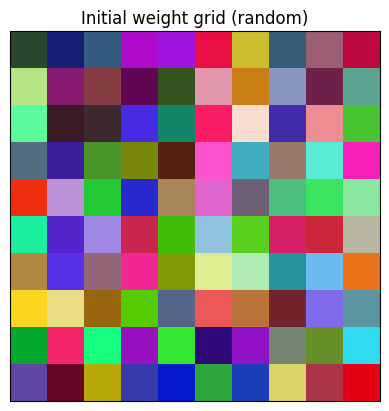

data    -> shape: (200, 3) | min: 0.0051 | max: 0.9997
weights -> shape: (10, 10, 3) | min: 0.0046 | max: 0.9969


In [4]:
data = np.random.rand(200, 3)              # 200 colors, values between 0 and 1
GRID = 10
weights = np.random.rand(GRID, GRID, 3)    # 10 x 10 neurons, 3 values each
initial_weights = weights.copy()           # keep a copy to compare later

plt.imshow(weights)
plt.title("Initial weight grid (random)")
plt.xticks([]); plt.yticks([])
plt.show()

print("data    -> shape:", data.shape,    "| min: %.4f | max: %.4f" % (data.min(), data.max()))
print("weights -> shape:", weights.shape, "| min: %.4f | max: %.4f" % (weights.min(), weights.max()))

## Task 2: Distance calculation
Distance of one color to all 100 neurons at once, no loops (NumPy broadcasting).

distance array shape: (10, 10)


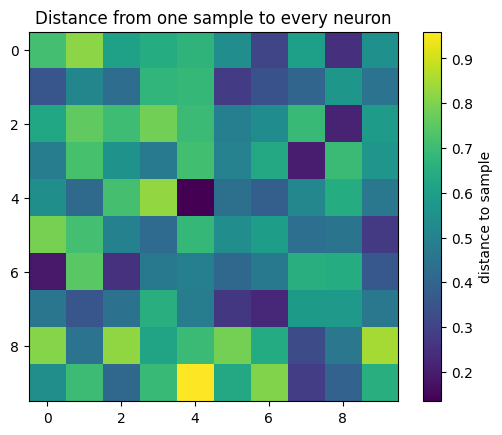

smallest distance = 0.1344 at row 4, column 4


In [5]:
def euclidean_distance(a, b):
    # works for two vectors, and also for a whole grid (..., 3) against one vector
    a, b = np.asarray(a), np.asarray(b)
    return np.sqrt(np.sum((a - b) ** 2, axis=-1))

x = data[np.random.randint(len(data))]        # one random sample
dist_map = euclidean_distance(weights, x)     # (10,10,3) minus (3,) -> (10,10)
print("distance array shape:", dist_map.shape)

plt.imshow(dist_map, cmap="viridis")
plt.colorbar(label="distance to sample")
plt.title("Distance from one sample to every neuron")
plt.show()

r, c = np.unravel_index(np.argmin(dist_map), dist_map.shape)
print(f"smallest distance = {dist_map.min():.4f} at row {r}, column {c}")

## Task 3: Finding the winner (BMU)
BMU = Best Matching Unit = the neuron with the smallest distance to the sample.

Sample  BMU (row, col)    Distance  
95      (2, 4)            0.1514    
112     (9, 7)            0.1481    
37      (8, 9)            0.1552    
151     (8, 1)            0.1024    
191     (5, 5)            0.1342    


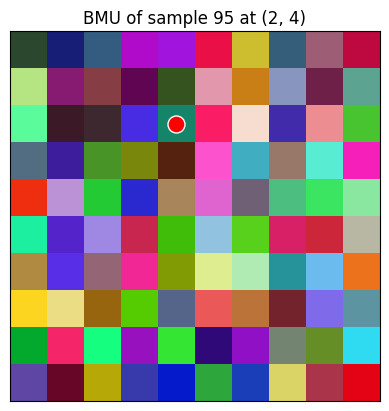

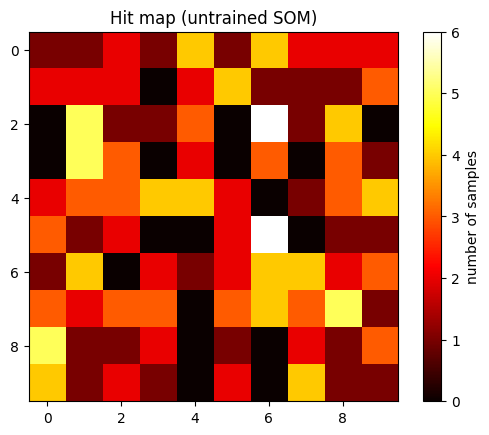

total hits = 200 (must be 200)


In [6]:
def find_bmu(weights, x):
    d = euclidean_distance(weights, x)
    row, col = np.unravel_index(np.argmin(d), d.shape)
    return int(row), int(col)

# 5 different samples
ids = np.random.choice(len(data), 5, replace=False)
print(f"{'Sample':<8}{'BMU (row, col)':<18}{'Distance':<10}")
for i in ids:
    bmu = find_bmu(weights, data[i])
    d = euclidean_distance(weights[bmu], data[i])
    print(f"{i:<8}{str(bmu):<18}{d:<10.4f}")

# mark the BMU of one sample with a red marker
s = data[ids[0]]
br, bc = find_bmu(weights, s)
plt.imshow(weights)
plt.scatter(bc, br, c="red", s=150, edgecolors="white")   # x = column, y = row
plt.title(f"BMU of sample {ids[0]} at ({br}, {bc})")
plt.xticks([]); plt.yticks([])
plt.show()

# hit map: how many of the 200 samples land on each neuron
hits = np.zeros((GRID, GRID), dtype=int)
for sample in data:
    r, c = find_bmu(weights, sample)
    hits[r, c] += 1

plt.imshow(hits, cmap="hot")
plt.colorbar(label="number of samples")
plt.title("Hit map (untrained SOM)")
plt.show()
print("total hits =", hits.sum(), "(must be 200)")

## Task 4: Neighborhood function
h = 1 at the winner and falls toward 0 as we move away. Radius controls how wide the circle of influence is.

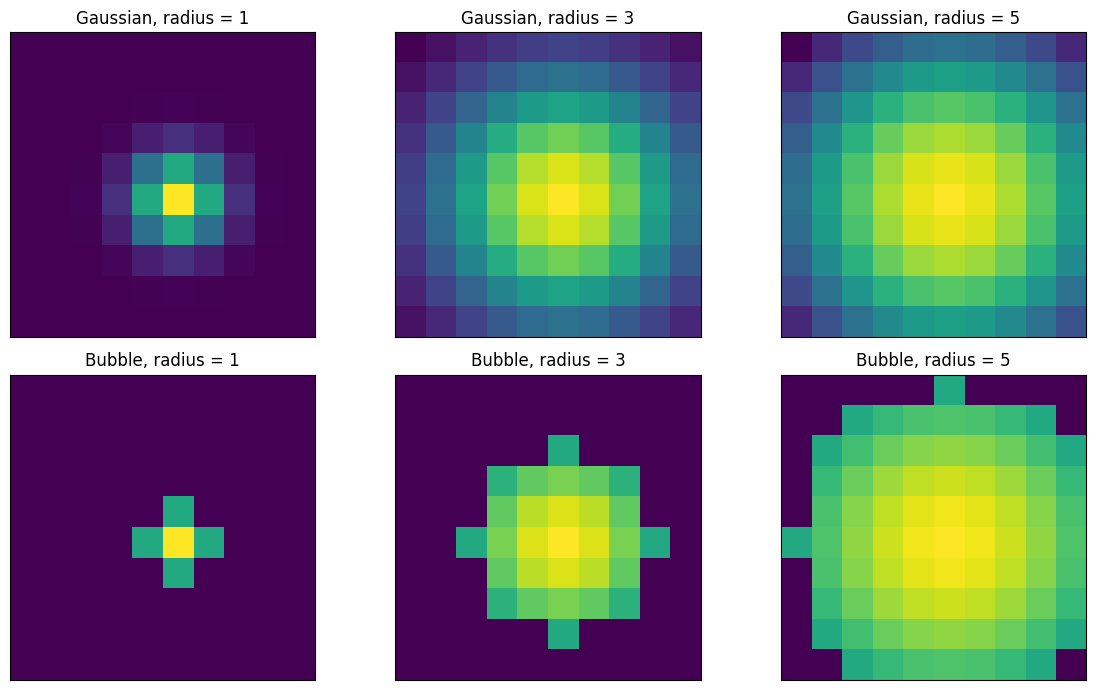

h at the BMU (5,5)          : 1.0
h at 3 steps away, (5,8)    : 0.3247


In [7]:
def neighborhood(grid_size, bmu, radius):
    # Gaussian: h = exp(-d^2 / (2 * radius^2)), d = grid distance to the BMU
    rows, cols = np.indices((grid_size, grid_size))
    d2 = (rows - bmu[0]) ** 2 + (cols - bmu[1]) ** 2
    return np.exp(-d2 / (2 * radius ** 2))

def neighborhood_bubble(grid_size, bmu, radius):
    # same as Gaussian, but 0 for every neuron farther than the radius
    rows, cols = np.indices((grid_size, grid_size))
    d2 = (rows - bmu[0]) ** 2 + (cols - bmu[1]) ** 2
    h = np.exp(-d2 / (2 * radius ** 2))
    h[d2 > radius ** 2] = 0
    return h

radii = [1, 3, 5]
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for k, rad in enumerate(radii):
    axes[0, k].imshow(neighborhood(10, (5, 5), rad), cmap="viridis")
    axes[0, k].set_title(f"Gaussian, radius = {rad}")
    axes[1, k].imshow(neighborhood_bubble(10, (5, 5), rad), cmap="viridis")
    axes[1, k].set_title(f"Bubble, radius = {rad}")
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

h2 = neighborhood(10, (5, 5), 2)
print("h at the BMU (5,5)          :", h2[5, 5])
print("h at 3 steps away, (5,8)    :", round(h2[5, 8], 4))

## Task 5: One weight update step
Rule: `w_new = w_old + learning_rate * h * (x - w_old)`. Each neuron moves toward the sample, more if it is close to the winner.

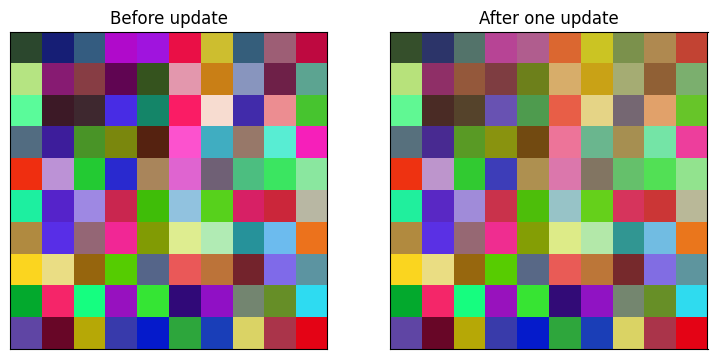

total absolute change in weights: 15.0262
BMU-to-sample distance: before = 0.1031, after = 0.0516
Confirmed: the distance decreased.


In [8]:
def update_weights(weights, x, bmu, learning_rate, radius):
    h = neighborhood(weights.shape[0], bmu, radius)
    # h[:, :, None] makes (10,10) into (10,10,1) so it multiplies all 3 color values
    return weights + learning_rate * h[:, :, np.newaxis] * (x - weights)

x = data[np.random.randint(len(data))]
bmu = find_bmu(weights, x)
new_weights = update_weights(weights, x, bmu, learning_rate=0.5, radius=3)

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
axes[0].imshow(weights);     axes[0].set_title("Before update")
axes[1].imshow(new_weights); axes[1].set_title("After one update")
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.show()

print("total absolute change in weights:", round(np.abs(new_weights - weights).sum(), 4))

before = euclidean_distance(weights[bmu], x)
after  = euclidean_distance(new_weights[bmu], x)
print(f"BMU-to-sample distance: before = {before:.4f}, after = {after:.4f}")
if after < before:
    print("Confirmed: the distance decreased.")
else:
    print("Distance did NOT decrease.")

## Task 6: Training loop
Repeat the step many times. Learning rate and radius shrink with `exp(-decay_rate * t / iterations)` (decay_rate = 3, so they end at about 5% of the start): big moves and wide neighborhood at the start, small careful moves at the end.

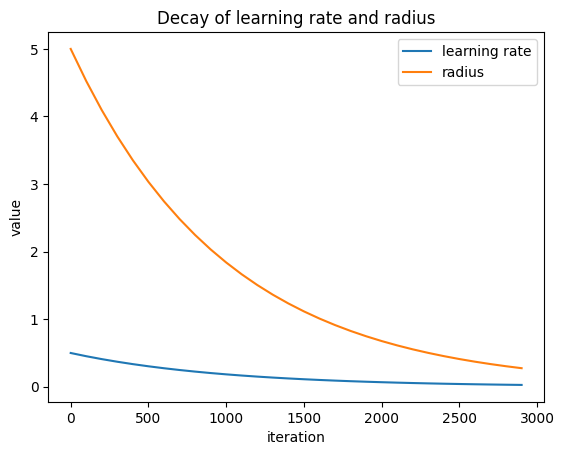

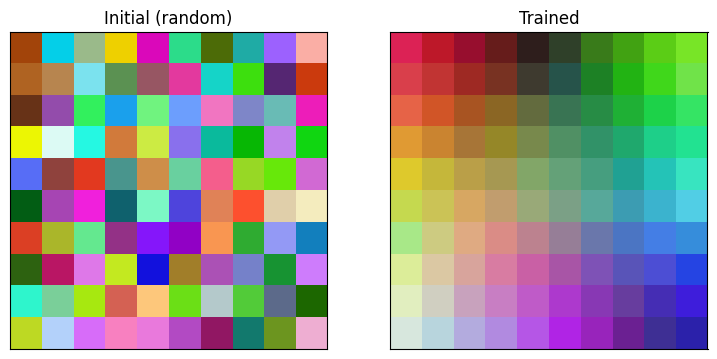

In [9]:
def train_som(data, grid_size, iterations, lr_start, radius_start, log=None, seed=0, decay_rate=3):
    rng = np.random.default_rng(seed)
    w = rng.random((grid_size, grid_size, 3))
    if log is not None:                      # the lists live in the log dictionary
        log["init"] = w.copy()
        log["lr"], log["radius"] = [], []

    for t in range(iterations):
        lr     = lr_start     * np.exp(-decay_rate * t / iterations)    # exponential decay
        radius = radius_start * np.exp(-decay_rate * t / iterations)

        x = data[rng.integers(len(data))]                  # random sample
        bmu = find_bmu(w, x)                               # winner
        h = neighborhood(grid_size, bmu, radius)           # neighbors
        w += lr * h[:, :, np.newaxis] * (x - w)            # update

        if log is not None and t % 100 == 0:               # store every 100 iterations
            log["lr"].append(lr)
            log["radius"].append(radius)
    return w

ITER = 3000
log6 = {}
trained = train_som(data, 10, ITER, lr_start=0.5, radius_start=5, log=log6)

steps = np.arange(0, ITER, 100)
plt.plot(steps, log6["lr"], label="learning rate")
plt.plot(steps, log6["radius"], label="radius")
plt.xlabel("iteration"); plt.ylabel("value")
plt.title("Decay of learning rate and radius")
plt.legend()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
axes[0].imshow(log6["init"]); axes[0].set_title("Initial (random)")
axes[1].imshow(trained);      axes[1].set_title("Trained")
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.savefig("task6_result.png", dpi=150, bbox_inches="tight")
plt.show()

## Task 7: Measuring training quality
Quantization error = average distance between each sample and its winner neuron. Lower = the map fits the data better.

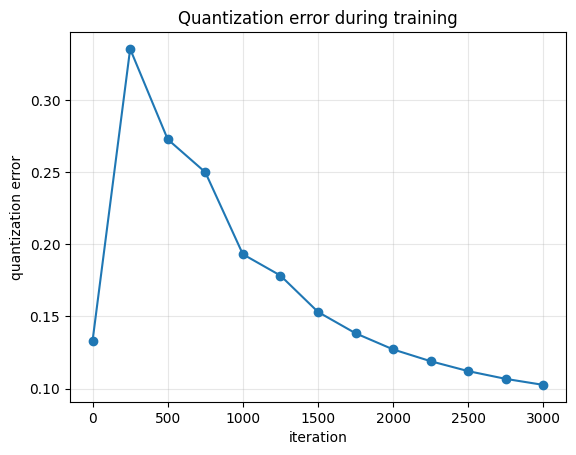

first error = 0.1332
last error  = 0.1025
reduction   = 23.03 %


In [10]:
def quantization_error(data, weights):
    flat = weights.reshape(-1, weights.shape[-1])                      # (n_neurons, 3)
    d = np.linalg.norm(data[:, None, :] - flat[None, :, :], axis=2)    # (n_samples, n_neurons)
    return d.min(axis=1).mean()      # smallest distance per sample = distance to its BMU

# training function again, now also recording the error every 250 iterations
def train_som(data, grid_size, iterations, lr_start, radius_start, log=None, seed=0, decay_rate=3):
    rng = np.random.default_rng(seed)
    w = rng.random((grid_size, grid_size, 3))
    if log is not None:
        log["init"] = w.copy()
        log["lr"], log["radius"] = [], []
        log["qe"], log["qe_iter"] = [], []

    for t in range(iterations):
        lr     = lr_start     * np.exp(-decay_rate * t / iterations)
        radius = radius_start * np.exp(-decay_rate * t / iterations)

        if log is not None and t % 250 == 0:               # error before this step
            log["qe"].append(quantization_error(data, w))
            log["qe_iter"].append(t)

        x = data[rng.integers(len(data))]
        bmu = find_bmu(w, x)
        h = neighborhood(grid_size, bmu, radius)
        w += lr * h[:, :, np.newaxis] * (x - w)

        if log is not None and t % 100 == 0:
            log["lr"].append(lr)
            log["radius"].append(radius)

    if log is not None:                                    # error of the finished map
        log["qe"].append(quantization_error(data, w))
        log["qe_iter"].append(iterations)
    return w

log7 = {}
trained = train_som(data, 10, 3000, 0.5, 5, log=log7)

plt.plot(log7["qe_iter"], log7["qe"], marker="o")
plt.xlabel("iteration")
plt.ylabel("quantization error")
plt.title("Quantization error during training")
plt.grid(alpha=0.3)
plt.show()

first, last = log7["qe"][0], log7["qe"][-1]
print(f"first error = {first:.4f}")
print(f"last error  = {last:.4f}")
print(f"reduction   = {(first - last) / first * 100:.2f} %")

## Task 8: Parameter experiments
Change one setting at a time and watch the map and the error.

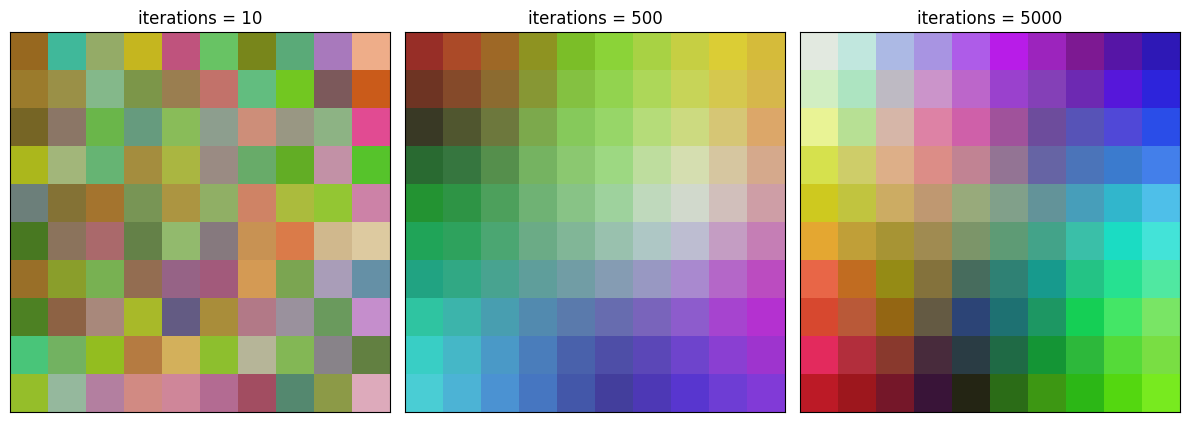

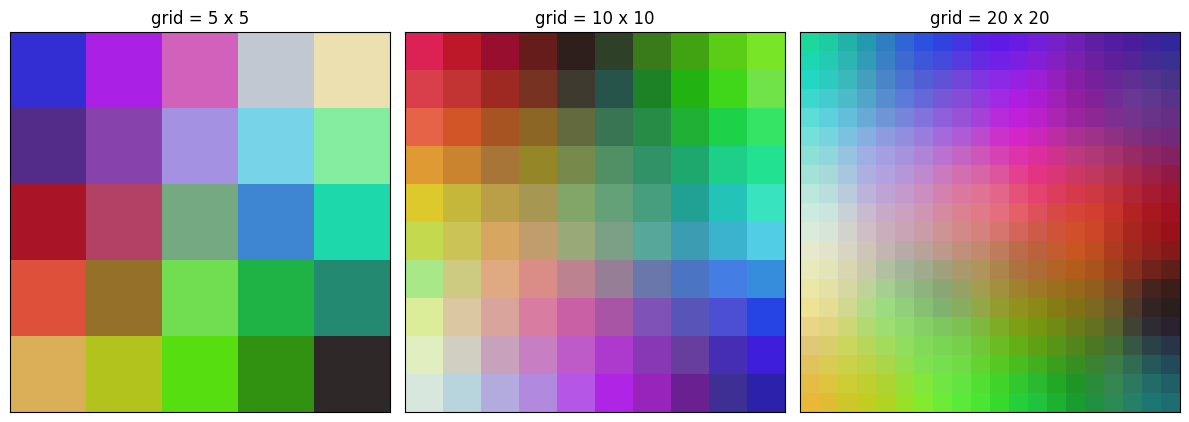

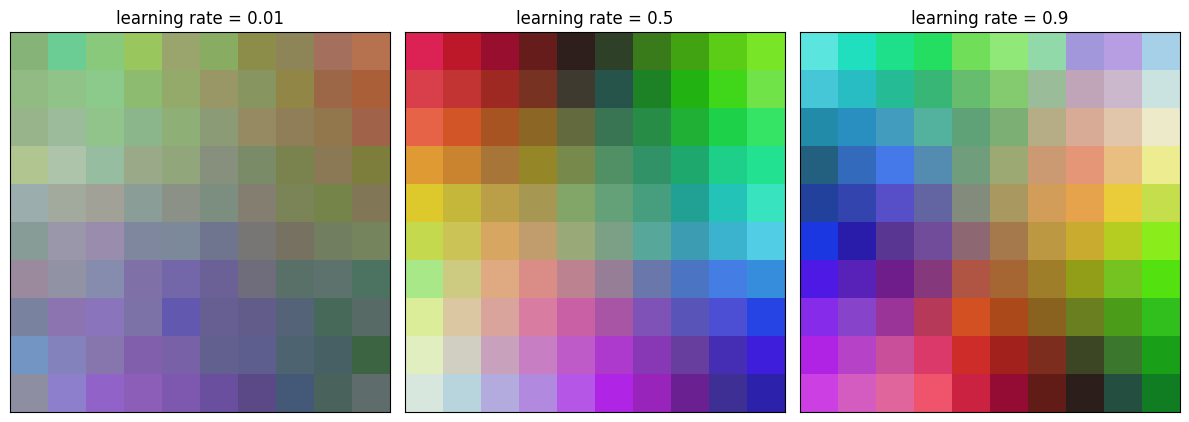

Setting        Value     Final error 
-------------------------------------
iterations     10        0.2208      
iterations     500       0.1565      
iterations     5000      0.0915      
grid size      5         0.1548      
grid size      10        0.1025      
grid size      20        0.0861      
learning rate  0.01      0.2610      
learning rate  0.5       0.1025      
learning rate  0.9       0.0909      


In [11]:
results = []   # (setting, value, final error)

# (a) number of iterations
fig, axes = plt.subplots(1, 3, figsize=(12, 4.2))
for ax, n in zip(axes, [10, 500, 5000]):
    w = train_som(data, 10, n, 0.5, 5)
    ax.imshow(w); ax.set_title(f"iterations = {n}")
    ax.set_xticks([]); ax.set_yticks([])
    results.append(("iterations", n, quantization_error(data, w)))
plt.tight_layout(); plt.show()

# (b) grid size (radius starts at half the grid)
fig, axes = plt.subplots(1, 3, figsize=(12, 4.2))
for ax, g in zip(axes, [5, 10, 20]):
    w = train_som(data, g, 3000, 0.5, g / 2)
    ax.imshow(w); ax.set_title(f"grid = {g} x {g}")
    ax.set_xticks([]); ax.set_yticks([])
    results.append(("grid size", g, quantization_error(data, w)))
plt.tight_layout(); plt.show()

# (c) learning rate
fig, axes = plt.subplots(1, 3, figsize=(12, 4.2))
for ax, lr in zip(axes, [0.01, 0.5, 0.9]):
    w = train_som(data, 10, 3000, lr, 5)
    ax.imshow(w); ax.set_title(f"learning rate = {lr}")
    ax.set_xticks([]); ax.set_yticks([])
    results.append(("learning rate", lr, quantization_error(data, w)))
plt.tight_layout(); plt.show()

# summary table
print(f"{'Setting':<15}{'Value':<10}{'Final error':<12}")
print("-" * 37)
for name, value, err in results:
    print(f"{name:<15}{str(value):<10}{err:<12.4f}")

## Task 9: Mini project - three base colors
Data is only noisy red, green and blue. A good SOM should show about three separate color regions.

sample range: 0.0 to 1.0


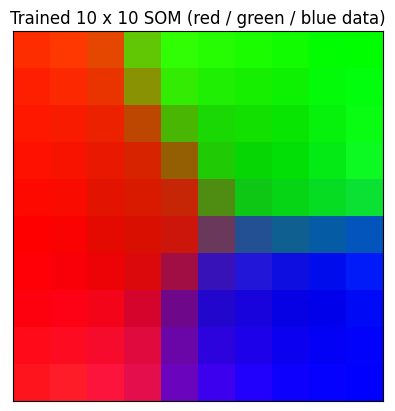

neurons that got at least one sample: 53 out of 100


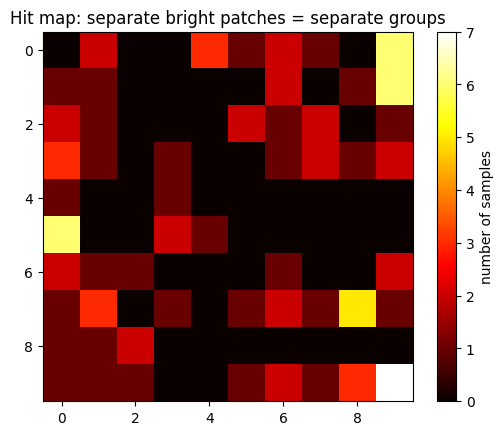

In [12]:
base = np.array([[1, 0, 0],    # red
                 [0, 1, 0],    # green
                 [0, 0, 1]])   # blue
pick = np.random.randint(0, 3, size=100)
noise = np.random.normal(0, 0.1, size=(100, 3))          # small noise
samples = np.clip(base[pick] + noise, 0, 1)              # keep values inside 0..1
print("sample range:", samples.min().round(3), "to", samples.max().round(3))

som9 = train_som(samples, 10, 3000, 0.5, 5)

plt.imshow(som9)
plt.title("Trained 10 x 10 SOM (red / green / blue data)")
plt.xticks([]); plt.yticks([])
plt.show()

# group samples by their BMU position
groups = {}
for i, s in enumerate(samples):
    groups.setdefault(find_bmu(som9, s), []).append(i)

print("neurons that got at least one sample:", len(groups), "out of 100")

hits9 = np.zeros((10, 10), dtype=int)
for (r, c), members in groups.items():
    hits9[r, c] = len(members)

plt.imshow(hits9, cmap="hot")
plt.colorbar(label="number of samples")
plt.title("Hit map: separate bright patches = separate groups")
plt.show()